# Machine Learning Capstone — Classification Track (Review 1)

**Course:** 23CSE301 Machine Learning
**Dataset:** BCI Competition IV (EEG Motor Imagery) — https://www.bbci.de/competition/iv/
**Track:** Classification (Part A — Review 1)

## Team Members & Roles

| Name | Roll No. | Role / Track Ownership |
|------|----------|--------------------------|
| _Member 1_ | _____ | Classification (primary) |
| _Member 2_ | _____ | Regression (primary) |
| _Member 3_ | _____ | Clustering (primary) |

## Problem Statement & Dataset Description

**Problem statement:** Classify the type of motor imagery task (e.g. left hand, right hand, feet,
tongue — dataset-dependent) a subject is performing, based on multi-channel EEG signals recorded
during a Brain-Computer Interface (BCI) experiment.

**Dataset:** [BCI Competition IV](https://www.bbci.de/competition/iv/) provides several datasets
(2a, 2b, etc.) of raw EEG recordings in GDF/MAT format, along with event markers indicating the
imagined movement class per trial.

**Note on raw signal data:** Unlike a typical CSV dataset, EEG data is a continuous multi-channel
time series. To use it with the standard classifiers required by this capstone (Logistic
Regression, KNN, Naive Bayes, Decision Tree, SVM), each trial must first be converted into a
**fixed-length feature vector**. We do this using **band-power features** (mu 8–12 Hz and beta
13–30 Hz power per EEG channel, via Welch's method), computed per trial. This turns the raw signal
into a standard tabular dataset (rows = trials, columns = band-power features, target = imagined
movement class) that the rest of the pipeline (EDA, cleaning, scaling, classification) operates on.

---

# 1. Dataset Loading & Audit
## 1.1 Import Libraries

In [1]:
# Core libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# EEG-specific
import mne
from scipy.signal import welch

# ML
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (8, 5)

mne.set_log_level("WARNING")
print("Libraries loaded.")

Libraries loaded.


## 1.2 Load Dataset

In [2]:
# ---------------------------------------------------------------------------
# Path to the raw BCI Competition IV files.
# Download the dataset (agree to the terms on the competition page) and place
# the .gdf (2a) or .mat (2b) files here, e.g.:
#   data/A01T.gdf, data/A02T.gdf, ...
# ---------------------------------------------------------------------------
DATA_DIR = "data/"
FILE_PATTERN = ".gdf"   # change to ".mat" if using dataset 2b

# Mu / beta band definitions used for feature extraction
BANDS = {"mu": (8, 12), "beta": (13, 30)}

def list_raw_files(data_dir, pattern):
    if not os.path.isdir(data_dir):
        return []
    return sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(pattern)])

raw_files = list_raw_files(DATA_DIR, FILE_PATTERN)
print(f"Found {len(raw_files)} raw EEG file(s) in '{DATA_DIR}'.")
if raw_files:
    print(raw_files)
else:
    print("No raw files found — will fall back to a synthetic EEG-like dataset below "
          "so the notebook still runs end-to-end. Replace with real data once downloaded.")

Found 0 raw EEG file(s) in 'data/'.
No raw files found — will fall back to a synthetic EEG-like dataset below so the notebook still runs end-to-end. Replace with real data once downloaded.


In [3]:
def extract_band_power_features(epochs_data, sfreq, bands=BANDS):
    """
    epochs_data : ndarray, shape (n_epochs, n_channels, n_times)
    Returns a DataFrame of shape (n_epochs, n_channels * n_bands) with Welch band-power features.
    """
    n_epochs, n_channels, n_times = epochs_data.shape
    feature_rows = []
    col_names = None

    for ep in range(n_epochs):
        row = {}
        for ch in range(n_channels):
            freqs, psd = welch(epochs_data[ep, ch, :], fs=sfreq, nperseg=min(256, n_times))
            for band_name, (lo, hi) in bands.items():
                mask = (freqs >= lo) & (freqs <= hi)
                band_power = np.trapz(psd[mask], freqs[mask]) if mask.any() else 0.0
                row[f"ch{ch+1}_{band_name}"] = band_power
        feature_rows.append(row)
        if col_names is None:
            col_names = list(row.keys())

    return pd.DataFrame(feature_rows, columns=col_names)


def load_bci_iv_2a(files):
    """Loads BCI Competition IV 2a GDF files with MNE, extracts epochs and event labels."""
    all_feats, all_labels = [], []
    for f in files:
        raw = mne.io.read_raw_gdf(f, preload=True)
        events, event_id = mne.events_from_annotations(raw)

        # Keep only motor-imagery cue events (dataset-specific codes; inspect event_id and adjust)
        mi_event_id = {k: v for k, v in event_id.items()
                        if any(tag in k for tag in ["769", "770", "771", "772"])}
        if not mi_event_id:
            mi_event_id = event_id  # fallback: use whatever annotations exist

        epochs = mne.Epochs(raw, events, event_id=mi_event_id,
                             tmin=0.5, tmax=2.5, baseline=None, preload=True)
        data = epochs.get_data()  # (n_epochs, n_channels, n_times)
        labels = epochs.events[:, -1]

        feats = extract_band_power_features(data, sfreq=raw.info["sfreq"])
        all_feats.append(feats)
        all_labels.append(labels)

    X = pd.concat(all_feats, ignore_index=True)
    y = np.concatenate(all_labels)
    return X, y


def make_synthetic_eeg_dataset(n_trials=400, n_channels=22, n_classes=4, random_state=RANDOM_STATE):
    """Synthetic stand-in: mimics band-power features from a 4-class motor-imagery task.
    Used ONLY so the notebook runs end-to-end before real data is downloaded."""
    rng = np.random.default_rng(random_state)
    class_names = ["left_hand", "right_hand", "feet", "tongue"][:n_classes]
    y = rng.integers(0, n_classes, size=n_trials)

    col_names = [f"ch{ch+1}_{band}" for ch in range(n_channels) for band in BANDS]
    X = pd.DataFrame(index=range(n_trials), columns=col_names, dtype=float)

    for c in range(n_classes):
        idx = np.where(y == c)[0]
        # give each class a distinct mean/variance per band so classifiers have signal to learn
        class_shift = rng.normal(loc=c * 1.5, scale=0.3, size=len(col_names))
        for j, col in enumerate(col_names):
            X.loc[idx, col] = rng.gamma(shape=2.0, scale=1.0 + abs(class_shift[j]), size=len(idx))

    y_named = np.array([class_names[c] for c in y])
    return X.astype(float), y_named


if raw_files:
    X_raw, y_raw = load_bci_iv_2a(raw_files)
    data_source = "real"
else:
    X_raw, y_raw = make_synthetic_eeg_dataset()
    data_source = "synthetic"

print(f"Data source: {data_source}")
print(f"Feature matrix shape: {X_raw.shape}")
print(f"Labels shape: {y_raw.shape}")

Data source: synthetic
Feature matrix shape: (400, 44)
Labels shape: (400,)


## 1.3 Shape, Data Types & Structure

In [4]:
df = X_raw.copy()
df["target"] = y_raw

print("Dataset shape:", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
df.head()

Dataset shape: (400, 45)

Data types:
ch1_mu       float64
ch1_beta     float64
ch2_mu       float64
ch2_beta     float64
ch3_mu       float64
ch3_beta     float64
ch4_mu       float64
ch4_beta     float64
ch5_mu       float64
ch5_beta     float64
ch6_mu       float64
ch6_beta     float64
ch7_mu       float64
ch7_beta     float64
ch8_mu       float64
ch8_beta     float64
ch9_mu       float64
ch9_beta     float64
ch10_mu      float64
ch10_beta    float64
ch11_mu      float64
ch11_beta    float64
ch12_mu      float64
ch12_beta    float64
ch13_mu      float64
ch13_beta    float64
ch14_mu      float64
ch14_beta    float64
ch15_mu      float64
ch15_beta    float64
ch16_mu      float64
ch16_beta    float64
ch17_mu      float64
ch17_beta    float64
ch18_mu      float64
ch18_beta    float64
ch19_mu      float64
ch19_beta    float64
ch20_mu      float64
ch20_beta    float64
ch21_mu      float64
ch21_beta    float64
ch22_mu      float64
ch22_beta    float64
target           str
dtype: object



,ch1_mu,ch1_beta,ch2_mu,ch2_beta,ch3_mu,ch3_beta,ch4_mu,ch4_beta,ch5_mu,ch5_beta,...,ch18_beta,ch19_mu,ch19_beta,ch20_mu,ch20_beta,ch21_mu,ch21_beta,ch22_mu,ch22_beta,target
0,0.920514,1.681037,2.355505,1.258524,0.714524,1.581033,2.729826,1.624663,3.723685,3.629045,...,1.601835,4.059230,1.401357,1.929281,1.053084,5.071824,0.756514,0.909392,2.331315,left_hand
1,9.716370,4.469976,1.551330,8.659847,12.593506,12.935510,12.297068,37.607214,19.968187,2.350079,...,8.895958,19.879313,8.635043,3.705202,9.079860,5.665969,2.580380,15.016916,12.382544,tongue
2,9.983642,7.204748,2.063443,8.826907,10.646313,14.489862,6.171585,10.762682,3.792756,2.536237,...,3.922356,10.429172,5.428195,3.400242,7.085492,12.471986,1.102680,2.525584,9.610675,feet
3,1.619119,2.481700,6.358603,2.446816,7.432928,2.491993,5.180149,1.695105,6.528202,2.367387,...,3.072231,1.061728,2.893946,1.151209,4.966316,6.865331,9.421804,1.551676,6.217483,right_hand
4,1.136138,9.334546,5.499437,7.795003,4.880574,4.029529,2.659493,1.453673,6.387921,8.855255,...,4.707220,7.443977,2.750642,1.869132,8.349987,6.025766,2.852751,1.335260,1.198400,right_hand


## 1.4 Missing Value Report

Columns with missing values:
No missing values found.


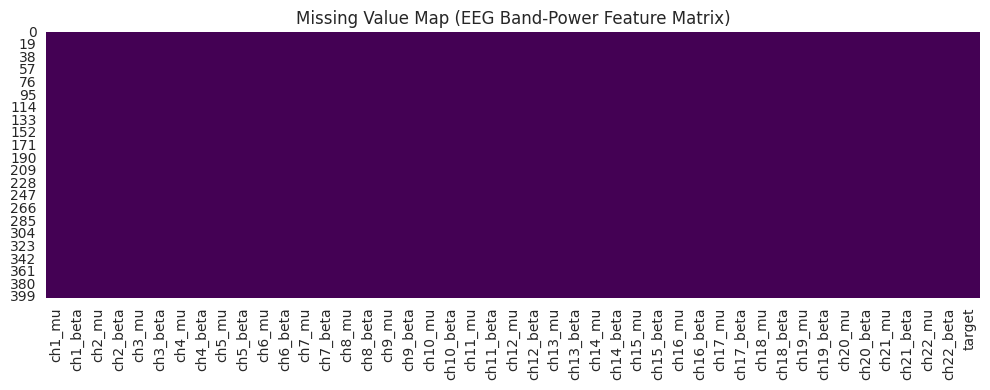

In [5]:
missing_report = df.isnull().sum()
missing_report = missing_report[missing_report > 0].sort_values(ascending=False)

print("Columns with missing values:")
print(missing_report if not missing_report.empty else "No missing values found.")

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Map (EEG Band-Power Feature Matrix)")
plt.tight_layout()
plt.show()

## 1.5 Class/Target Distribution

target
right_hand    110
left_hand      97
tongue         97
feet           96
Name: count, dtype: int64


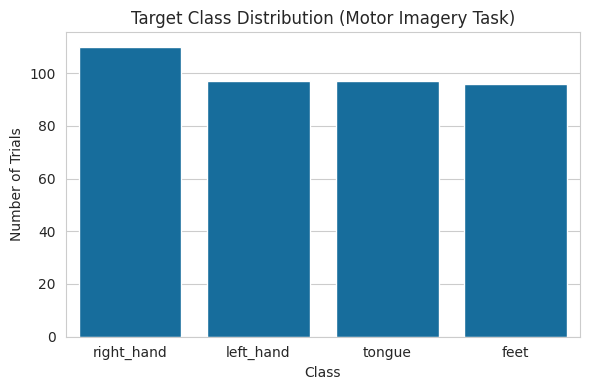

In [6]:
class_counts = df["target"].value_counts()
print(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x="target", data=df, order=class_counts.index)
plt.title("Target Class Distribution (Motor Imagery Task)")
plt.xlabel("Class")
plt.ylabel("Number of Trials")
plt.tight_layout()
plt.show()

**Observation:** _Record here whether the classes are balanced. If imbalanced, note that
stratified splitting (Section 4.3) and weighted F1 (Section 6) will be used to account for it._

---

# 2. Exploratory Data Analysis (EDA)
## 2.1 Feature Distribution Plots

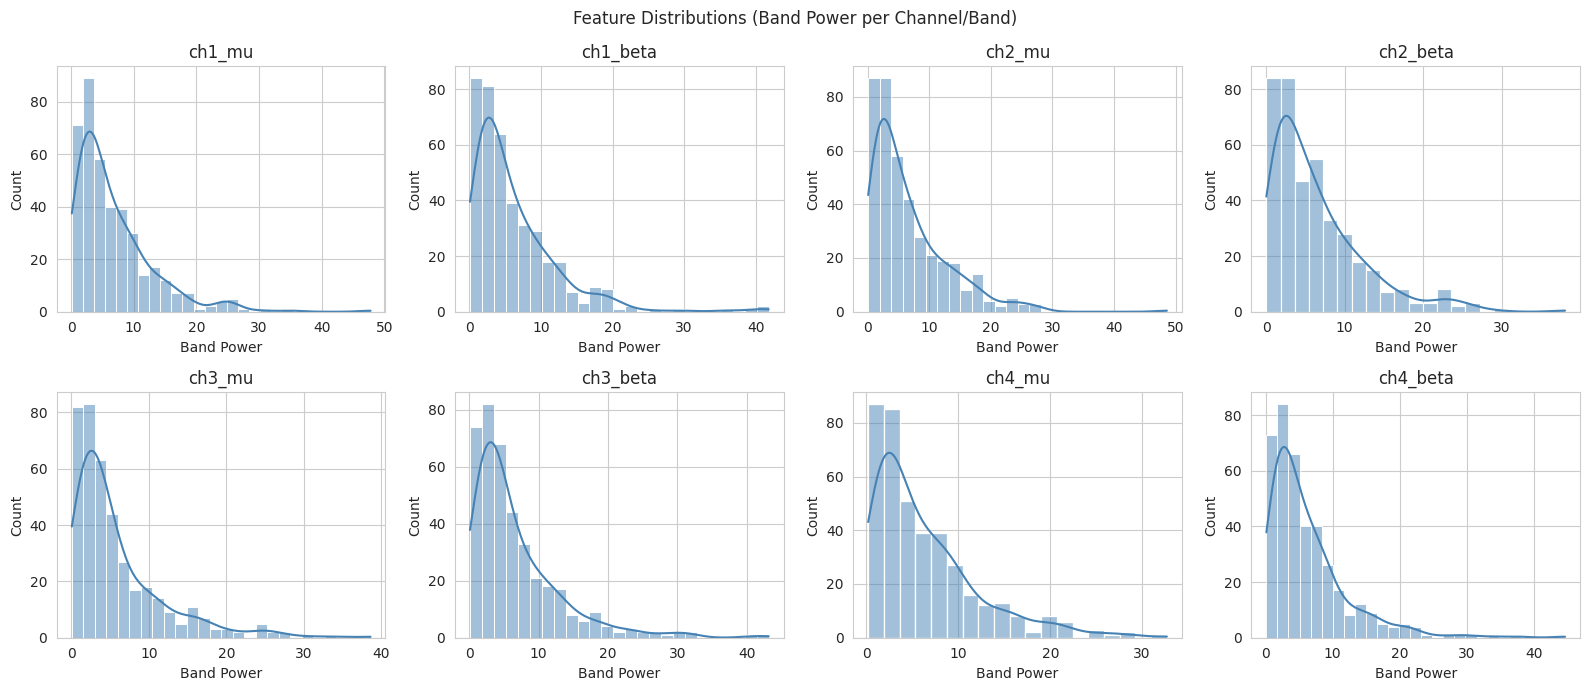

In [7]:
feature_cols = [c for c in df.columns if c != "target"]

# Plot distributions for a representative subset of channels (first 8 features)
subset = feature_cols[:8]
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, subset):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("Band Power")
fig.suptitle("Feature Distributions (Band Power per Channel/Band)")
plt.tight_layout()
plt.show()

## 2.2 Correlation Heatmap

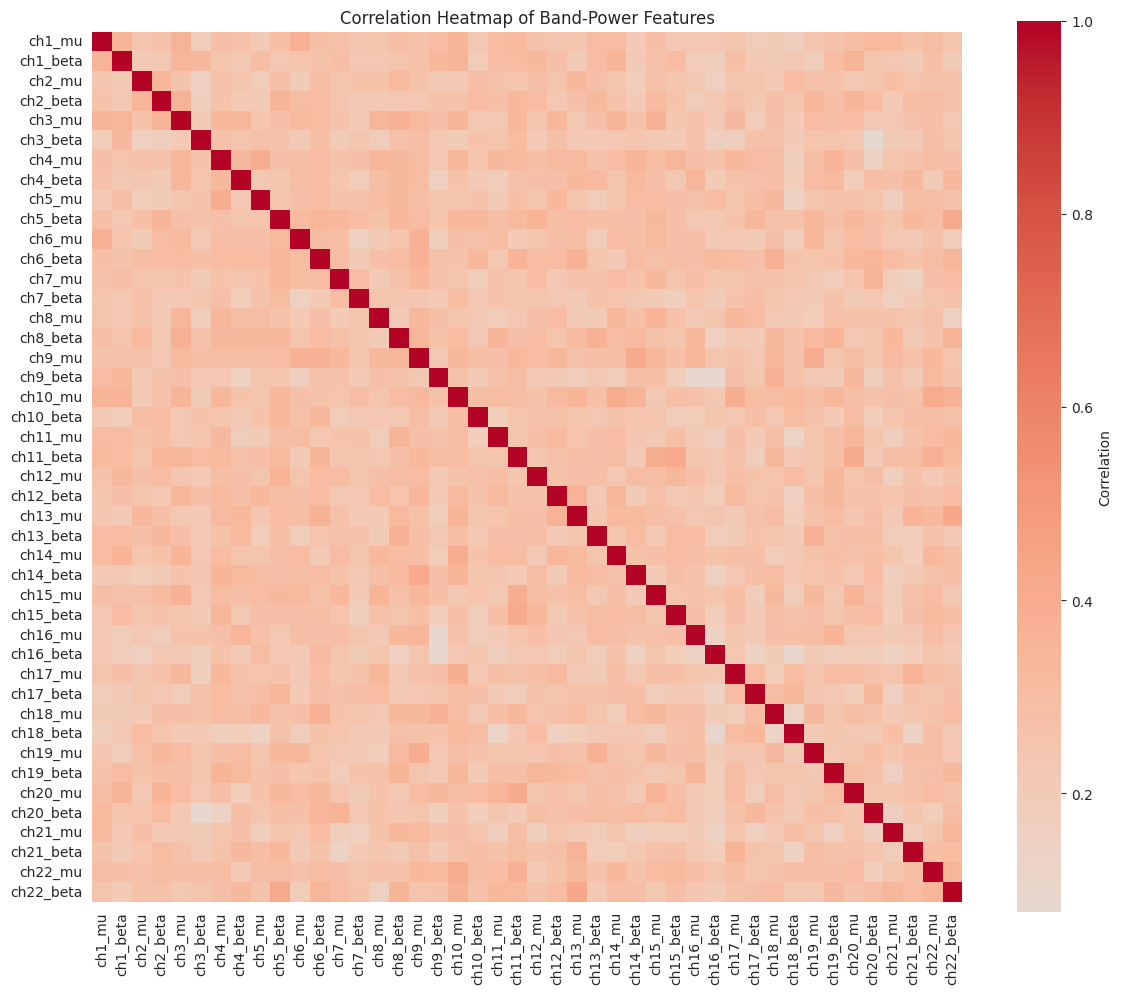

In [8]:
plt.figure(figsize=(12, 10))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"label": "Correlation"})
plt.title("Correlation Heatmap of Band-Power Features")
plt.tight_layout()
plt.show()

## 2.3 Target Class Distribution Plot

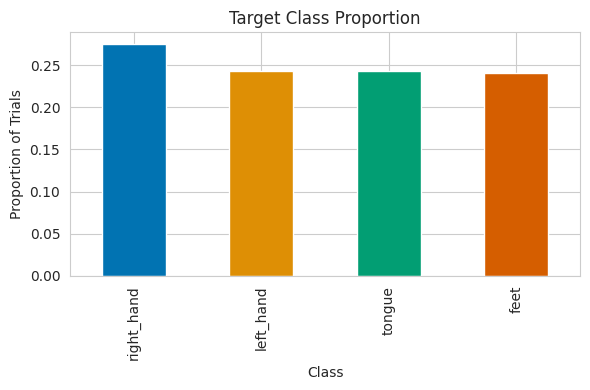

In [9]:
plt.figure(figsize=(6, 4))
df["target"].value_counts(normalize=True).plot(kind="bar", color=sns.color_palette("colorblind"))
plt.title("Target Class Proportion")
plt.xlabel("Class")
plt.ylabel("Proportion of Trials")
plt.tight_layout()
plt.show()

## 2.4 Feature-vs-Target Scatter Plots (min. 2)

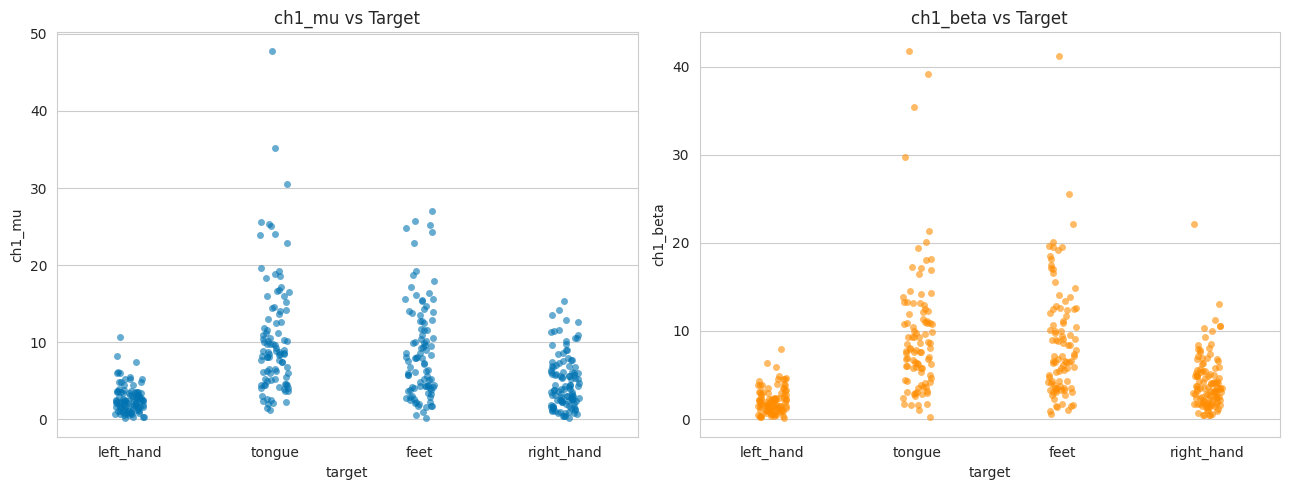

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.stripplot(x="target", y=feature_cols[0], data=df, ax=axes[0], jitter=True, alpha=0.6)
axes[0].set_title(f"{feature_cols[0]} vs Target")

sns.stripplot(x="target", y=feature_cols[1], data=df, ax=axes[1], jitter=True, alpha=0.6, color="darkorange")
axes[1].set_title(f"{feature_cols[1]} vs Target")

plt.tight_layout()
plt.show()

## 2.5 Insight Commentary

- **Feature distributions:** _Note skewness, outliers, or multi-modality per band/channel here._
- **Correlation heatmap:** _Note any highly correlated channel/band pairs (expected, since
  neighbouring electrodes pick up correlated signal) and whether that motivates
  dimensionality reduction._
- **Class distribution:** _State whether classes are balanced/imbalanced and the implication for
  metric choice._
- **Scatter plots:** _Note whether the chosen features visibly separate classes — this hints at
  which channels/bands are most discriminative for motor imagery._

---

# 3. Data Cleaning
## 3.1 Handling Missing Values (strategy + justification)

In [11]:
# Band-power features computed via Welch's method are numeric and rarely produce NaNs,
# but artifact-corrupted epochs can occasionally yield them. Strategy: median imputation
# per column (robust to the outliers typical of EEG artifacts).

if df[feature_cols].isnull().sum().sum() > 0:
    df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())
    print("Missing values imputed with column-wise median.")
else:
    print("No missing values present — no imputation needed.")

No missing values present — no imputation needed.


## 3.2 Duplicate Check & Treatment

In [12]:
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

if n_duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


## 3.3 Outlier Detection & Treatment

Total outlier values capped (IQR rule, factor=1.5): 926


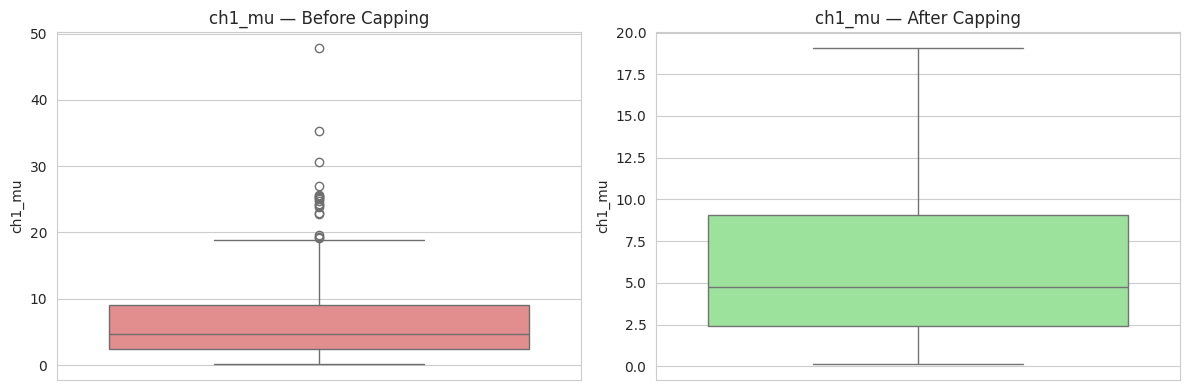

In [13]:
# EEG band-power is naturally right-skewed and can contain extreme values from
# eye-blink / muscle artifacts. Use the IQR rule per feature to CAP (winsorize) rather
# than drop, so we don't lose whole trials.

def cap_outliers_iqr(data, cols, factor=1.5):
    data = data.copy()
    capped_count = 0
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - factor * iqr, q3 + factor * iqr
        before = ((data[col] < lower) | (data[col] > upper)).sum()
        data[col] = data[col].clip(lower, upper)
        capped_count += before
    return data, capped_count

df_before = df.copy()
df, n_capped = cap_outliers_iqr(df, feature_cols)
print(f"Total outlier values capped (IQR rule, factor=1.5): {n_capped}")

# Visual check: before vs after for one feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_before[feature_cols[0]], ax=axes[0], color="lightcoral")
axes[0].set_title(f"{feature_cols[0]} — Before Capping")
sns.boxplot(y=df[feature_cols[0]], ax=axes[1], color="lightgreen")
axes[1].set_title(f"{feature_cols[0]} — After Capping")
plt.tight_layout()
plt.show()

---

# 4. Preprocessing & Feature Engineering
## 4.1 Encoding Categorical Variables

In [14]:
le = LabelEncoder()
df["target_encoded"] = le.fit_transform(df["target"])

print("Class mapping:")
for cls, code_val in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {code_val}")

Class mapping:
  feet -> 0
  left_hand -> 1
  right_hand -> 2
  tongue -> 3


## 4.2 Feature Scaling (fit on train only)

## 4.3 Train/Test Split (stratified)

In [15]:
X = df[feature_cols].values
y = df["target_encoded"].values

# Split FIRST, then fit the scaler on the training set only to avoid data leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)          # transform test using train statistics

print(f"Train set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test class balance:  {np.bincount(y_test)}")

Train set: (320, 44), Test set: (80, 44)
Train class balance: [77 77 88 78]
Test class balance:  [19 20 22 19]


## 4.4 Feature Engineering (new feature + justification)

In [16]:
# Engineered feature: mu/beta power RATIO per channel.
# Justification: motor imagery is known to produce Event-Related Desynchronization (ERD) in the
# mu band and Event-Related Synchronization (ERS) in the beta band over the sensorimotor cortex.
# The RATIO between these bands per channel is a compact way to capture this class-discriminative
# pattern in a single feature, rather than relying on the raw powers separately.

channels = sorted(set(c.split("_")[0] for c in feature_cols))
for ch in channels:
    mu_col, beta_col = f"{ch}_mu", f"{ch}_beta"
    if mu_col in df.columns and beta_col in df.columns:
        df[f"{ch}_mu_beta_ratio"] = df[mu_col] / (df[beta_col] + 1e-6)

engineered_cols = [c for c in df.columns if c.endswith("_ratio")]
print(f"Engineered {len(engineered_cols)} mu/beta ratio features, e.g.: {engineered_cols[:3]}")

# Rebuild train/test arrays including the engineered features
all_feature_cols = feature_cols + engineered_cols
X_full = df[all_feature_cols].values

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final feature count (incl. engineered): {X_train_scaled.shape[1]}")

Engineered 22 mu/beta ratio features, e.g.: ['ch1_mu_beta_ratio', 'ch10_mu_beta_ratio', 'ch11_mu_beta_ratio']
Final feature count (incl. engineered): 66


---

# 5. Classification Track — Part A
## 5.1 Logistic Regression

In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

# Interpret coefficients: which features push toward which class most strongly (class 0 shown)
coef_df = pd.DataFrame(log_reg.coef_, columns=all_feature_cols, index=le.classes_[:log_reg.coef_.shape[0]])
print("Top 5 features by |coefficient| for first class:")
print(coef_df.iloc[0].abs().sort_values(ascending=False).head(5))

Top 5 features by |coefficient| for first class:
ch13_mu              0.693780
ch1_beta             0.668518
ch13_beta            0.475411
ch20_mu              0.447246
ch9_mu_beta_ratio    0.398231
Name: feet, dtype: float64


## 5.2 K-Nearest Neighbors

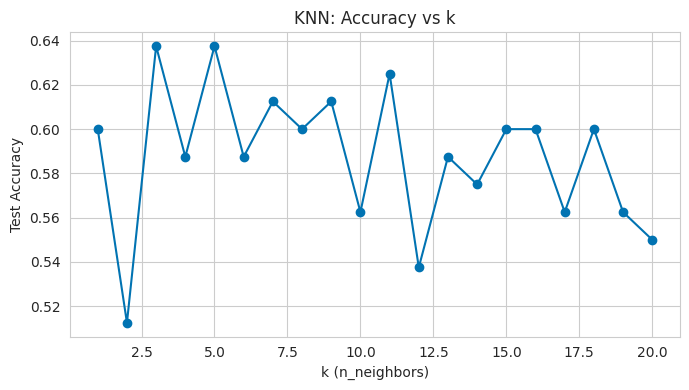

Best k found: 3


In [18]:
# Quick k sweep to justify the chosen k
k_range = range(1, 21)
k_scores = [KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
                .score(X_test_scaled, y_test) for k in k_range]

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), k_scores, marker="o")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Test Accuracy")
plt.title("KNN: Accuracy vs k")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(k_scores))]
print(f"Best k found: {best_k}")

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

## 5.3 Naive Bayes (Gaussian)

In [19]:
# Note: Gaussian Naive Bayes assumes each feature is conditionally independent given the class,
# and normally distributed. This is a strong assumption for EEG band-power features (which are
# correlated across neighbouring channels), so we expect this to be a weaker baseline.
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred_nb = nb.predict(X_test_scaled)

## 5.4 Decision Tree Classifier

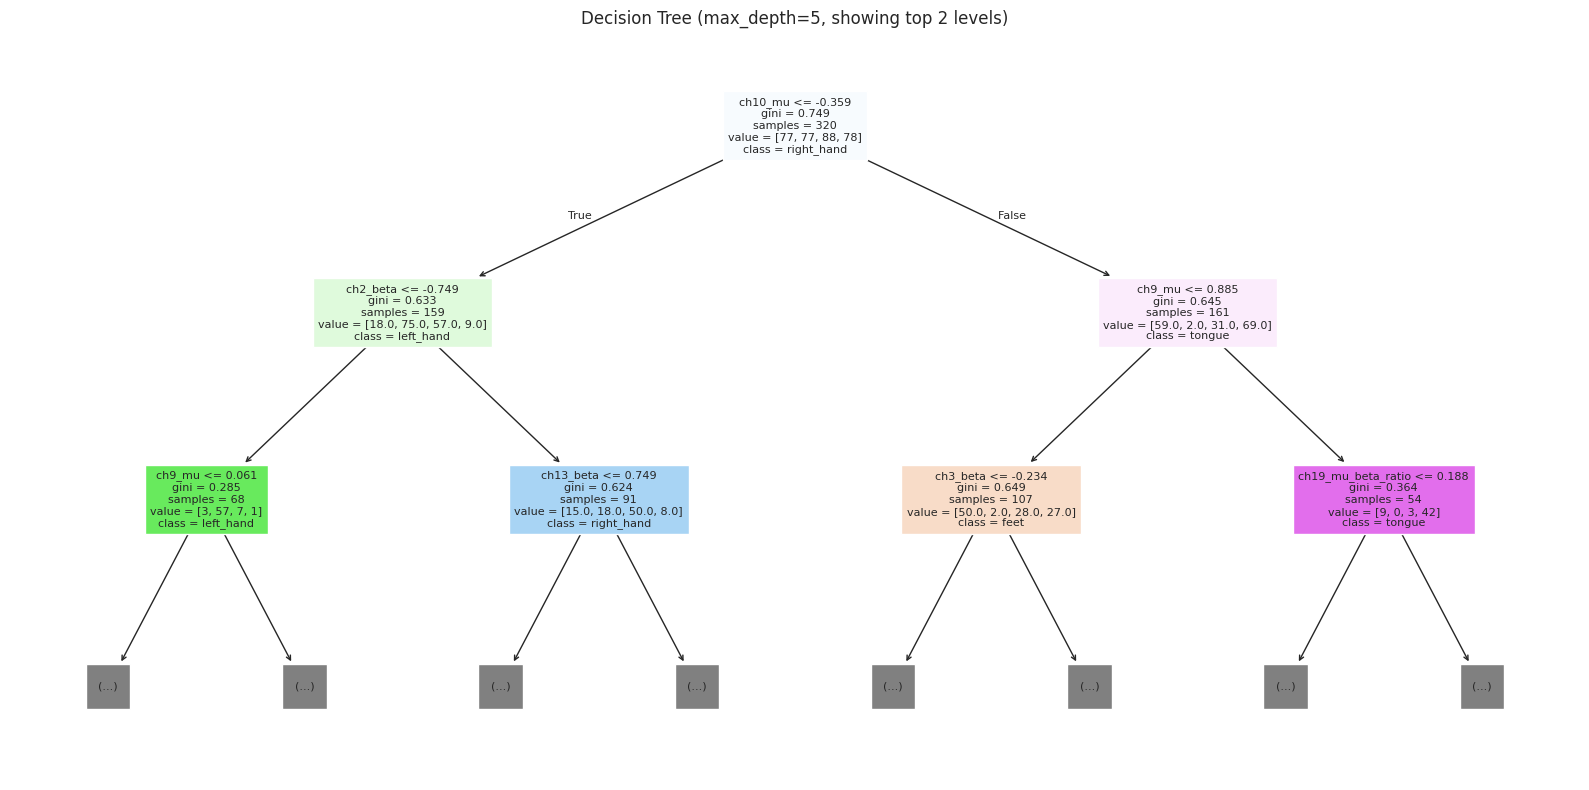

In [20]:
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

plt.figure(figsize=(16, 8))
plot_tree(dt, max_depth=2, feature_names=all_feature_cols, class_names=le.classes_,
          filled=True, fontsize=8)
plt.title("Decision Tree (max_depth=5, showing top 2 levels)")
plt.tight_layout()
plt.show()

## 5.5 Support Vector Machine (SVC)

In [21]:
svc = SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE)
svc.fit(X_train_scaled, y_train)
y_pred_svc = svc.predict(X_test_scaled)
print("SVC trained (features already scaled in Section 4.2).")

SVC trained (features already scaled in Section 4.2).


---

# 6. Part A — Model Evaluation
## 6.1 Accuracy, Weighted F1, Confusion Matrix per Algorithm

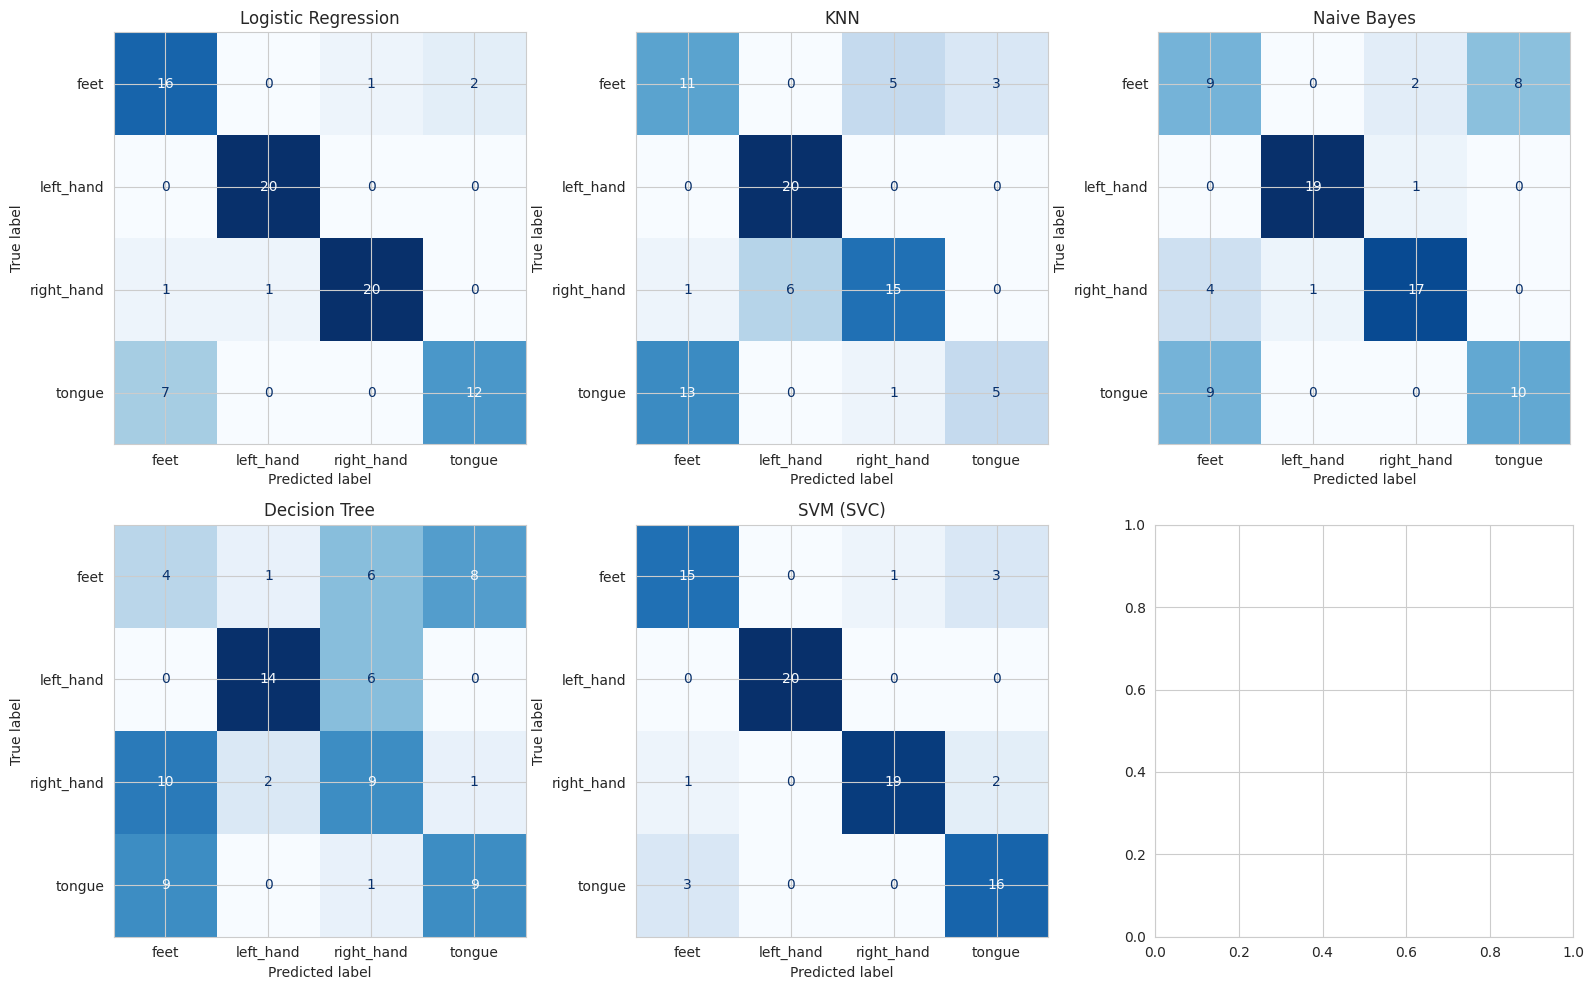

--- Logistic Regression ---
              precision    recall  f1-score   support

        feet       0.67      0.84      0.74        19
   left_hand       0.95      1.00      0.98        20
  right_hand       0.95      0.91      0.93        22
      tongue       0.86      0.63      0.73        19

    accuracy                           0.85        80
   macro avg       0.86      0.85      0.84        80
weighted avg       0.86      0.85      0.85        80

--- KNN ---
              precision    recall  f1-score   support

        feet       0.44      0.58      0.50        19
   left_hand       0.77      1.00      0.87        20
  right_hand       0.71      0.68      0.70        22
      tongue       0.62      0.26      0.37        19

    accuracy                           0.64        80
   macro avg       0.64      0.63      0.61        80
weighted avg       0.64      0.64      0.62        80

--- Naive Bayes ---
              precision    recall  f1-score   support

        feet   

In [22]:
models_part_a = {
    "Logistic Regression": (log_reg, y_pred_lr),
    "KNN": (knn, y_pred_knn),
    "Naive Bayes": (nb, y_pred_nb),
    "Decision Tree": (dt, y_pred_dt),
    "SVM (SVC)": (svc, y_pred_svc),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flat

for ax, (name, (model, y_pred)) in zip(axes, models_part_a.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

# hide any unused subplot
for ax in list(axes)[len(models_part_a):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

for name, (model, y_pred) in models_part_a.items():
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

## 6.2 Preliminary Comparison Table (all 5 models)

In [23]:
results = []
for name, (model, y_pred) in models_part_a.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (weighted)": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall (weighted)": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "F1 (weighted)": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1 (weighted)", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
0,SVM (SVC),0.8750,0.879702,0.8750,0.876310
1,Logistic Regression,0.8500,0.861905,0.8500,0.849188
2,Naive Bayes,0.6875,0.700354,0.6875,0.692766
3,KNN,0.6375,0.641674,0.6375,0.615965
4,Decision Tree,0.4500,0.478437,0.4500,0.462468


/tmp/ipykernel_148/3509448334.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="F1 (weighted)", y="Model", data=results_df, palette="colorblind")


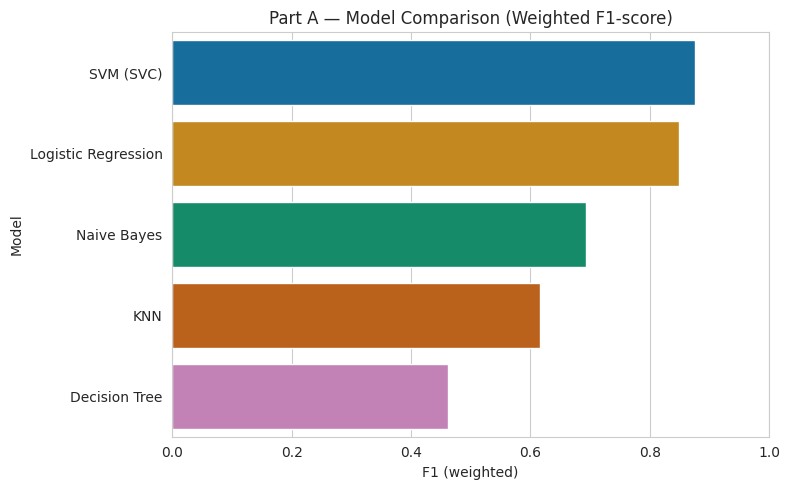

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x="F1 (weighted)", y="Model", data=results_df, palette="colorblind")
plt.title("Part A — Model Comparison (Weighted F1-score)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

---

# 7. Conclusion (Part A)
## 7.1 Observations

_Summarise: which of the 5 Part-A models performed best and why (e.g. SVM handling non-linear
class boundaries better than Logistic Regression; Naive Bayes underperforming due to correlated
features violating its independence assumption, etc.). Reference the comparison table above._

## 7.2 What Part B Will Add

Part B (Review 2) will extend this notebook with Random Forest, AdaBoost, Gradient Boosting,
Bagging, and an MLP Classifier, followed by a consolidated 10-model comparison table
(Accuracy, Precision, Recall, F1, ROC-AUC), hyperparameter tuning via GridSearchCV/RandomizedSearchCV
on at least two models, and 5-fold cross-validation on the two best-performing models.

---

# 8. References & AI-Tool Acknowledgement

- BCI Competition IV dataset: https://www.bbci.de/competition/iv/
- scikit-learn documentation: https://scikit-learn.org/
- MNE-Python (EEG processing): https://mne.tools/
- _Cite any StackOverflow/blog snippets used, and any Generative AI assistance, here per the
  academic integrity policy._